In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("azure_Based_demand_Forecasting_Data_raw.csv") # loads our csv file inot a dataframe
print(df)

     timestamp       region service_type  usage_units  provisioned_capacity  \
0   2024-01-01      US-East      Compute       8200.0                  9000   
1   2024-01-02      US East      Compute          NaN                  9000   
2   2024-01-03      US-East      Compute       8100.0                  9000   
3   2024-01-04      us-east      Compute       8450.0                  9000   
4   2024-01-04      us-east      Compute       8450.0                  9000   
5   2024-01-06      US-East      Compute       8800.0                  9000   
6   2024-01-07      US-East      Compute       8600.0                  9000   
7   2024-01-01  India South      Storage       8000.0                 10000   
8   2024-01-02  India-South      Storage       8100.0                 10000   
9   2024-01-04  India-South      Storage          NaN                 10000   
10  2024-01-05  India-South      Storage       8800.0                 10000   
11  2024-01-07  India-South      Storage       8500.

In [2]:
df['timestamp'] = pd.to_datetime(df['timestamp']) #converts the string data inot datetime objects
df = df.sort_values(by='timestamp') # sorting is mandatory for the time-series
print(df)

    timestamp       region service_type  usage_units  provisioned_capacity  \
0  2024-01-01      US-East      Compute       8200.0                  9000   
7  2024-01-01  India South      Storage       8000.0                 10000   
1  2024-01-02      US East      Compute          NaN                  9000   
8  2024-01-02  India-South      Storage       8100.0                 10000   
2  2024-01-03      US-East      Compute       8100.0                  9000   
3  2024-01-04      us-east      Compute       8450.0                  9000   
4  2024-01-04      us-east      Compute       8450.0                  9000   
9  2024-01-04  India-South      Storage          NaN                 10000   
10 2024-01-05  India-South      Storage       8800.0                 10000   
5  2024-01-06      US-East      Compute       8800.0                  9000   
6  2024-01-07      US-East      Compute       8600.0                  9000   
11 2024-01-07  India-South      Storage       8500.0            

In [3]:
df['region'] = df['region'].str.lower().str.replace(" ", "-")# str.lower- removes the case diff
#.replaces- standaridizes the formatting


df['region'] = df['region'].replace({ # .replace- maps the variants to canoniical names.
    'us-east': 'US-East',
    'india-south': 'India-South'
})
print(df)

    timestamp       region service_type  usage_units  provisioned_capacity  \
0  2024-01-01      US-East      Compute       8200.0                  9000   
7  2024-01-01  India-South      Storage       8000.0                 10000   
1  2024-01-02      US-East      Compute          NaN                  9000   
8  2024-01-02  India-South      Storage       8100.0                 10000   
2  2024-01-03      US-East      Compute       8100.0                  9000   
3  2024-01-04      US-East      Compute       8450.0                  9000   
4  2024-01-04      US-East      Compute       8450.0                  9000   
9  2024-01-04  India-South      Storage          NaN                 10000   
10 2024-01-05  India-South      Storage       8800.0                 10000   
5  2024-01-06      US-East      Compute       8800.0                  9000   
6  2024-01-07      US-East      Compute       8600.0                  9000   
11 2024-01-07  India-South      Storage       8500.0            

In [4]:
df = df.drop_duplicates() # keeps the first occurances
print(df)

    timestamp       region service_type  usage_units  provisioned_capacity  \
0  2024-01-01      US-East      Compute       8200.0                  9000   
7  2024-01-01  India-South      Storage       8000.0                 10000   
1  2024-01-02      US-East      Compute          NaN                  9000   
8  2024-01-02  India-South      Storage       8100.0                 10000   
2  2024-01-03      US-East      Compute       8100.0                  9000   
3  2024-01-04      US-East      Compute       8450.0                  9000   
9  2024-01-04  India-South      Storage          NaN                 10000   
10 2024-01-05  India-South      Storage       8800.0                 10000   
5  2024-01-06      US-East      Compute       8800.0                  9000   
6  2024-01-07      US-East      Compute       8600.0                  9000   
11 2024-01-07  India-South      Storage       8500.0                 10000   

    cost_usd  availability_pct  is_holiday  
0     4100.0      

In [5]:
df['usage_units'] = df['usage_units'].interpolate()# usage units- time dependent
# handling missing value- col wise
# interpolate preserves trend

In [6]:
df['cost_usd'] = df['cost_usd'].fillna(
    df['usage_units'] * 0.5
)
#cost- derived from the usage unit
# recomputing instead of guessing mean

In [7]:
df['availability_pct'] = df['availability_pct'].fillna(method='ffill')
# fowrard fill is reasonable

/tmp/ipython-input-866449406.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['availability_pct'] = df['availability_pct'].fillna(method='ffill')


In [8]:
df['is_holiday'] = df['is_holiday'].fillna(0)

In [9]:
df.isnull().sum()


,0
timestamp,0
region,0
service_type,0
usage_units,0
provisioned_capacity,0
cost_usd,0
availability_pct,0
is_holiday,0


,usage_units
region,
India-South,"Axes(0.125,0.11;0.775x0.77)"
US-East,"Axes(0.125,0.11;0.775x0.77)"


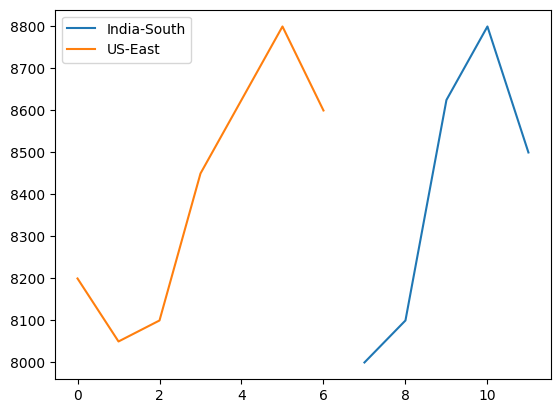

In [10]:
df.groupby('region')['usage_units'].plot(legend=True)


Milestone 2

In [11]:
df = df.sort_values("timestamp").reset_index(drop=True)
print(df)
# ensures that there is a crt chronologically order
# required for the lag, rolling, and spike calcul

    timestamp       region service_type  usage_units  provisioned_capacity  \
0  2024-01-01      US-East      Compute       8200.0                  9000   
1  2024-01-01  India-South      Storage       8000.0                 10000   
2  2024-01-02      US-East      Compute       8050.0                  9000   
3  2024-01-02  India-South      Storage       8100.0                 10000   
4  2024-01-03      US-East      Compute       8100.0                  9000   
5  2024-01-04      US-East      Compute       8450.0                  9000   
6  2024-01-04  India-South      Storage       8625.0                 10000   
7  2024-01-05  India-South      Storage       8800.0                 10000   
8  2024-01-06      US-East      Compute       8800.0                  9000   
9  2024-01-07      US-East      Compute       8600.0                  9000   
10 2024-01-07  India-South      Storage       8500.0                 10000   

    cost_usd  availability_pct  is_holiday  
0     4100.0      

In [12]:
#creating time features
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["weekday"] = df["timestamp"].dt.weekday
# df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)
print(df)

# captures seasonlity and human behaviour patterns
# weeedays/weekend- differences often drive the cloud usage

    timestamp       region service_type  usage_units  provisioned_capacity  \
0  2024-01-01      US-East      Compute       8200.0                  9000   
1  2024-01-01  India-South      Storage       8000.0                 10000   
2  2024-01-02      US-East      Compute       8050.0                  9000   
3  2024-01-02  India-South      Storage       8100.0                 10000   
4  2024-01-03      US-East      Compute       8100.0                  9000   
5  2024-01-04      US-East      Compute       8450.0                  9000   
6  2024-01-04  India-South      Storage       8625.0                 10000   
7  2024-01-05  India-South      Storage       8800.0                 10000   
8  2024-01-06      US-East      Compute       8800.0                  9000   
9  2024-01-07      US-East      Compute       8600.0                  9000   
10 2024-01-07  India-South      Storage       8500.0                 10000   

    cost_usd  availability_pct  is_holiday  hour  day  weekday 

What is a Lag Feature?

A lag feature means: “Use past values to help predict the future.”

It literally shifts the column down so each row can “see” previous values.

📊 Example
```
Time	Usage	Lag 1
10 AM	100	    NaN
11 AM	120 	100
12 PM	130	    120
```



So at 11 AM, the model knows what usage was at 10 AM.

In [13]:
df["lag_1_usage"] = df["usage_units"].shift(1) # lag1- short-term memory- captures immediate effect
df["lag_7_usage"] = df["usage_units"].shift(7) # lag7- weekely pattern- Captures recurring cycles
print(df)

    timestamp       region service_type  usage_units  provisioned_capacity  \
0  2024-01-01      US-East      Compute       8200.0                  9000   
1  2024-01-01  India-South      Storage       8000.0                 10000   
2  2024-01-02      US-East      Compute       8050.0                  9000   
3  2024-01-02  India-South      Storage       8100.0                 10000   
4  2024-01-03      US-East      Compute       8100.0                  9000   
5  2024-01-04      US-East      Compute       8450.0                  9000   
6  2024-01-04  India-South      Storage       8625.0                 10000   
7  2024-01-05  India-South      Storage       8800.0                 10000   
8  2024-01-06      US-East      Compute       8800.0                  9000   
9  2024-01-07      US-East      Compute       8600.0                  9000   
10 2024-01-07  India-South      Storage       8500.0                 10000   

    cost_usd  availability_pct  is_holiday  hour  day  weekday 

What is Rolling Mean?

Rolling mean calculates the average of the last N values.

It smooths noise and shows trend.

Example

Usage:
100, 120, 130

Rolling mean (window=3):

(100 + 120 + 130) / 3 = 116.6

Without rolling mean

The model sees sudden jumps as patterns → leads to overfitting.

In [14]:
df["rolling_mean_3"] = df["usage_units"].rolling(window=3).mean()
print(df)

    timestamp       region service_type  usage_units  provisioned_capacity  \
0  2024-01-01      US-East      Compute       8200.0                  9000   
1  2024-01-01  India-South      Storage       8000.0                 10000   
2  2024-01-02      US-East      Compute       8050.0                  9000   
3  2024-01-02  India-South      Storage       8100.0                 10000   
4  2024-01-03      US-East      Compute       8100.0                  9000   
5  2024-01-04      US-East      Compute       8450.0                  9000   
6  2024-01-04  India-South      Storage       8625.0                 10000   
7  2024-01-05  India-South      Storage       8800.0                 10000   
8  2024-01-06      US-East      Compute       8800.0                  9000   
9  2024-01-07      US-East      Compute       8600.0                  9000   
10 2024-01-07  India-South      Storage       8500.0                 10000   

    cost_usd  availability_pct  is_holiday  hour  day  weekday 

What is Spike Detection?

It creates a flag showing whether usage is unusually high.

Example

Mean = 100
Std = 20

Threshold = 120

```
Usage	Spike
90	    0
100	    0
130	    1
```



In [15]:
threshold = df["usage_units"].mean() + df["usage_units"].std()
df["usage_spike"] = np.where(df["usage_units"] > threshold, 1, 0)
print(df)

    timestamp       region service_type  usage_units  provisioned_capacity  \
0  2024-01-01      US-East      Compute       8200.0                  9000   
1  2024-01-01  India-South      Storage       8000.0                 10000   
2  2024-01-02      US-East      Compute       8050.0                  9000   
3  2024-01-02  India-South      Storage       8100.0                 10000   
4  2024-01-03      US-East      Compute       8100.0                  9000   
5  2024-01-04      US-East      Compute       8450.0                  9000   
6  2024-01-04  India-South      Storage       8625.0                 10000   
7  2024-01-05  India-South      Storage       8800.0                 10000   
8  2024-01-06      US-East      Compute       8800.0                  9000   
9  2024-01-07      US-East      Compute       8600.0                  9000   
10 2024-01-07  India-South      Storage       8500.0                 10000   

    cost_usd  availability_pct  is_holiday  hour  day  weekday 

What is Encoding?

Machine learning models only understand numbers.

Categorical data must be converted.

Example

Region column:

Region
US
EU

Becomes:

Region_US
1
0

In [16]:
df = pd.get_dummies(df, columns=["region", "service_type"], drop_first=True)


Final Dataset Check:

*   Confirm no nulls exist
*   Check data types and columns
*   Validate feature creation success


In [ ]:
df.info()
df.head()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             11 non-null     datetime64[ns]
 1   usage_units           11 non-null     float64       
 2   provisioned_capacity  11 non-null     int64         
 3   cost_usd              11 non-null     float64       
 4   availability_pct      11 non-null     float64       
 5   is_holiday            11 non-null     float64       
 6   hour                  11 non-null     int32         
 7   day                   11 non-null     int32         
 8   weekday               11 non-null     int32         
 9   lag_1_usage           10 non-null     float64       
 10  lag_7_usage           4 non-null      float64       
 11  rolling_mean_3        9 non-null      float64       
 12  usage_spike           11 non-null     int64         
 13  region_US-East        

,0
timestamp,0
usage_units,0
provisioned_capacity,0
cost_usd,0
availability_pct,0
is_holiday,0
hour,0
day,0
weekday,0
lag_1_usage,1
